# Perform single-cell quality control

> Note: There will be commented out code for displaying the CytoDataFrames as it is helpful to switch between views during optimization.

In [1]:
import pathlib
import re
import time

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

from cytodataframe import CytoDataFrame
from cosmicqc import find_outliers, label_outliers


In [2]:
# Set parameters for papermill to use for processing
plate_id = "BR00149544"

# Whether to render per-condition image diagnostics (CytoDataFrame previews of
# outlier crops, pulled from the bandicoot network mount). This is the slow
# part of this notebook and is only useful for interactive review -- the
# final label_outliers export below only depends on the *_thresholds dicts,
# not on these previews. Batch/papermill runs across many plates should set
# this to False.
render_diagnostics = True


In [3]:
# Directory containing the converted profiles after merging
data_dir = pathlib.Path("./data/merged_profiles/")

# Directory to save qc results from cosmicqc
cleaned_dir = pathlib.Path("./data/qc_results")
cleaned_dir.mkdir(exist_ok=True)


In [4]:
compartments = ["Nuclei", "Cells"]

shared_metadata_columns = [
    "Image_Metadata_Plate",
    "Image_Metadata_Well",
    "Image_Metadata_Site",
    "Image_Metadata_Row",
    "Image_Metadata_Col",
    "Image_FileName_OrigDNA",
    "Image_FileName_OrigAGP",
    "Image_PathName_OrigDNA",
    "Image_PathName_OrigAGP",
    # per-cell identifiers needed to join qc annotations back onto the
    # full single-cell profile after pycytominer's annotate step
    "Metadata_ImageNumber",
    "Metadata_Cells_Number_Object_Number",
    "Metadata_Nuclei_Number_Object_Number",
]

compartment_location_templates = [
    "Metadata_{compartment}_Location_Center_X",
    "Metadata_{compartment}_Location_Center_Y",
    "{compartment}_AreaShape_BoundingBoxMaximum_X",
    "{compartment}_AreaShape_BoundingBoxMaximum_Y",
    "{compartment}_AreaShape_BoundingBoxMinimum_X",
    "{compartment}_AreaShape_BoundingBoxMinimum_Y",
]

compartment_qc_feature_templates = [
    "{compartment}_Intensity_IntegratedIntensity_DNA",
    "{compartment}_AreaShape_Solidity",
    "{compartment}_Intensity_MassDisplacement_DNA",
]

metadata_columns = shared_metadata_columns + [
    template.format(compartment=compartment)
    for compartment in compartments
    for template in compartment_location_templates
]

needed_columns = metadata_columns + [
    template.format(compartment=compartment)
    for compartment in compartments
    for template in compartment_qc_feature_templates
]


In [5]:
# Construct the file path for the given plate_id
file_path = data_dir / f"{plate_id}.parquet"

if file_path.exists():
    start_time = time.time()  # Start timer for loading

    # Load the DataFrame with pandas
    plate_df = pd.read_parquet(file_path, engine="pyarrow", columns=needed_columns)

    end_time = time.time()  # End timer for loading
    print(
        f"Loaded plate: {plate_id}, Shape: {plate_df.shape}, Time taken: {end_time - start_time:.2f} seconds"
    )
else:
    print(f"Parquet file for plate {plate_id} not found.")


Loaded plate: BR00149544, Shape: (584772, 30), Time taken: 0.97 seconds


In [6]:
# Confirm PathName is a column in input DataFrame
assert "Image_PathName_OrigDNA" in plate_df.columns, "Column 'Image_PathName_OrigDNA' is missing from the input DataFrame"


In [7]:
correct_parent = "/home/jenna/mnt/bandicoot/PCCMA_data"

for col in plate_df.columns:
    if "PathName" in col and "Illum" not in col:
        plate_df[col] = plate_df[col].apply(
            lambda x: (
                re.sub(r"^.*ALSF_screen_data/", correct_parent + "/", x)
                if isinstance(x, str)
                else x
            )
        )

# Print example image path after fix
print(plate_df["Image_PathName_OrigDNA"].dropna().iloc[0])


/home/jenna/mnt/bandicoot/PCCMA_data/CHP-134_repo1_screen/BR00149544__2026-02-09T20_10_07-Measurement 1/Images


## Run QC with `nuclei` features

In [8]:
# Set the compartment of choice to perform QC at the start (will change later)
compartment = "Nuclei"

# create an outline and orig mapping dictionary to map original images to outlines
# note: we turn off formatting here to avoid the key-value pairing definition
# from being reformatted by black, which is normally preferred.
# fmt: off
outline_to_orig_mapping = {
    rf"{compartment}Outlines_{record['Image_Metadata_Plate']}_{record['Image_Metadata_Well']}_{record['Image_Metadata_Site']}.tiff": 
    rf"r{int(record['Image_Metadata_Row']):02d}c{int(record['Image_Metadata_Col']):02d}f{int(record['Image_Metadata_Site']):02d}p(\d{{2}})-ch\d+sk\d+fk\d+fl\d+\.tiff"
    for record in plate_df[
        [
            "Image_Metadata_Plate",
            "Image_Metadata_Well",
            "Image_Metadata_Site",
            "Image_Metadata_Row",
            "Image_Metadata_Col",
        ]
    ].to_dict(orient="records")
}
# fmt: on

next(iter(outline_to_orig_mapping.items()))


('NucleiOutlines_BR00149544_A07_9.tiff',
 'r01c07f09p(\\d{2})-ch\\d+sk\\d+fk\\d+fl\\d+\\.tiff')

Number of outliers: 18041 (3.09%)
Outliers Range:
Nuclei_Intensity_MassDisplacement_DNA Min: 0.45143192316310066
Nuclei_Intensity_MassDisplacement_DNA Max: 5.612190728070413
Nuclei_Intensity_IntegratedIntensity_DNA Min: 13.174592718482018
Nuclei_Intensity_IntegratedIntensity_DNA Max: 143.6416513323784
(18041, 3)


,Image_FileName_OrigDNA,Nuclei_Intensity_MassDisplacement_DNA,Nuclei_Intensity_IntegratedIntensity_DNA
334825,,0.585496,143.641651
382399,,1.411712,56.352058
556486,,1.331083,55.671590
282029,,0.665779,54.984158
364206,,1.816740,54.250819

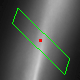
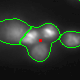
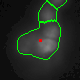
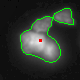
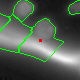

In [9]:
# Find large nuclei outliers for the current plate
nuclei_clustered_thresholds = {
    "Nuclei_Intensity_MassDisplacement_DNA": 0.7,
    "Nuclei_Intensity_IntegratedIntensity_DNA": 1.5,
}

nuclei_clustered_outliers = find_outliers(
    df=plate_df,
    metadata_columns=metadata_columns,
    feature_thresholds=nuclei_clustered_thresholds,
)

if render_diagnostics:
    # MUST SET DATA AS DATAFRAME FOR OUTLINE DIR TO WORK
    nuclei_clustered_outliers_cdf = CytoDataFrame(
        data=pd.DataFrame(nuclei_clustered_outliers),
        data_outline_context_dir=f"/home/jenna/mnt/bandicoot/PCCMA_data/CHP-134_repo1_screen_outputs/SQLite_outputs/{plate_id}",
        segmentation_file_regex=outline_to_orig_mapping,
        display_options={
            "brightness": 1,
            "offset_bounding_box": {
                "x_min": -40,
                "y_min": -40,
                "x_max": 40,
                "y_max": 40,
            },
        },
    )[
        [
            "Image_FileName_OrigDNA",
            "Nuclei_Intensity_MassDisplacement_DNA",
            "Nuclei_Intensity_IntegratedIntensity_DNA",
        ]
    ]

    print(nuclei_clustered_outliers_cdf.shape)
    display(
        nuclei_clustered_outliers_cdf.sort_values(
            by="Nuclei_Intensity_IntegratedIntensity_DNA", ascending=False
        ).head(5)
    )
    # nuclei_clustered_outliers_cdf.sample(n=2, random_state=0)


Number of outliers: 14455 (2.47%)
Outliers Range:
Nuclei_AreaShape_Solidity Min: 0.5222929936305732
Nuclei_AreaShape_Solidity Max: 0.8977272727272727
(14455, 2)


,Image_FileName_OrigDNA,Nuclei_AreaShape_Solidity
311390,,0.897727
155201,,0.897727
516843,,0.897727
216822,,0.897727
46645,,0.897727

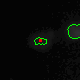
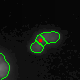
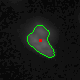
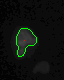
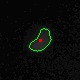

In [10]:
# Find low nuclei solidity outliers for the current plate
missegmented_nuclei_thresholds = {
    "Nuclei_AreaShape_Solidity": -2.5,
}

solidity_nuclei_outliers = find_outliers(
    df=plate_df,
    metadata_columns=metadata_columns,
    feature_thresholds=missegmented_nuclei_thresholds,
)

if render_diagnostics:
    # MUST SET DATA AS DATAFRAME FOR OUTLINE DIR TO WORK
    solidity_nuclei_outliers_cdf = CytoDataFrame(
        data=pd.DataFrame(solidity_nuclei_outliers),
        data_outline_context_dir=f"/home/jenna/mnt/bandicoot/PCCMA_data/CHP-134_repo1_screen_outputs/SQLite_outputs/{plate_id}",
        segmentation_file_regex=outline_to_orig_mapping,
        display_options={
            "brightness": 1,
            "offset_bounding_box": {
                "x_min": -40,
                "y_min": -40,
                "x_max": 40,
                "y_max": 40,
            },
        },
    )[
        [
            "Image_FileName_OrigDNA",
            "Nuclei_AreaShape_Solidity",
        ]
    ]

    print(solidity_nuclei_outliers_cdf.shape)
    display(
        solidity_nuclei_outliers_cdf.sort_values(
            by="Nuclei_AreaShape_Solidity", ascending=False
        ).head(5)
    )
    # solidity_nuclei_outliers_cdf.sample(n=5)


Number of outliers: 2411 (0.41%)
Outliers Range:
Nuclei_Intensity_IntegratedIntensity_DNA Min: 0.4458011072129011
Nuclei_Intensity_IntegratedIntensity_DNA Max: 1.1765316324308515
(2411, 2)


,Image_FileName_OrigDNA,Nuclei_Intensity_IntegratedIntensity_DNA
160299,,1.176532
455327,,1.176425
558728,,1.176393
164584,,1.176191
118624,,1.176071

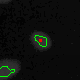
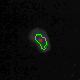
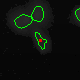
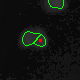
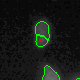

In [11]:
# Find background segmented as nuclei outliers for the current plate
background_segmentation_thresholds = {
    "Nuclei_Intensity_IntegratedIntensity_DNA": -1.8,
}

background_segmentation_outliers = find_outliers(
    df=plate_df,
    metadata_columns=metadata_columns,
    feature_thresholds=background_segmentation_thresholds,
)

if render_diagnostics:
    # MUST SET DATA AS DATAFRAME FOR OUTLINE DIR TO WORK
    background_segmentation_outliers_cdf = CytoDataFrame(
        data=pd.DataFrame(background_segmentation_outliers),
        data_outline_context_dir=f"/home/jenna/mnt/bandicoot/PCCMA_data/CHP-134_repo1_screen_outputs/SQLite_outputs/{plate_id}",
        segmentation_file_regex=outline_to_orig_mapping,
        display_options={
            "brightness": 1,
            "offset_bounding_box": {
                "x_min": -40,
                "y_min": -40,
                "x_max": 40,
                "y_max": 40,
            },
        },
    )[
        [
            "Image_FileName_OrigDNA",
            "Nuclei_Intensity_IntegratedIntensity_DNA",
        ]
    ]

    print(background_segmentation_outliers_cdf.shape)
    display(
        background_segmentation_outliers_cdf.sort_values(
            by="Nuclei_Intensity_IntegratedIntensity_DNA", ascending=False
        ).head(5)
    )
    # background_segmentation_outliers_cdf.sample(n=2, random_state=0)


## Run QC with `cell` features

In [12]:
# Set the compartment of choice to perform QC at the start (will change later)
compartment = "Cells"

# create an outline and orig mapping dictionary to map original images to outlines
# note: we turn off formatting here to avoid the key-value pairing definition
# from being reformatted by black, which is normally preferred.
# fmt: off
outline_to_orig_mapping_cells = {
    rf"{compartment}Outlines_{record['Image_Metadata_Plate']}_{record['Image_Metadata_Well']}_{record['Image_Metadata_Site']}.tiff": 
    rf"r{int(record['Image_Metadata_Row']):02d}c{int(record['Image_Metadata_Col']):02d}f{int(record['Image_Metadata_Site']):02d}p(\d{{2}})-ch\d+sk\d+fk\d+fl\d+\.tiff"
    for record in plate_df[
        [
            "Image_Metadata_Plate",
            "Image_Metadata_Well",
            "Image_Metadata_Site",
            "Image_Metadata_Row",
            "Image_Metadata_Col",
        ]
    ].to_dict(orient="records")
}
# fmt: on

next(iter(outline_to_orig_mapping_cells.items()))


('CellsOutlines_BR00149544_A07_9.tiff',
 'r01c07f09p(\\d{2})-ch\\d+sk\\d+fk\\d+fl\\d+\\.tiff')

Number of outliers: 10961 (1.87%)
Outliers Range:
Cells_Intensity_IntegratedIntensity_DNA Min: 21.40444269264117
Cells_Intensity_IntegratedIntensity_DNA Max: 1403.5685419086367
(10961, 3)


,Image_FileName_OrigDNA,Image_FileName_OrigAGP,Cells_Intensity_IntegratedIntensity_DNA
345686,,,1403.568542
344805,,,1017.896776
344160,,,943.180679
343314,,,762.017311
346048,,,716.031447

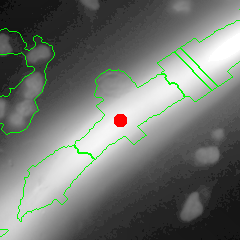
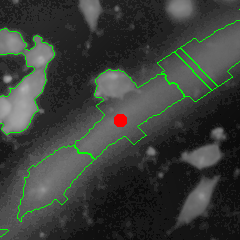
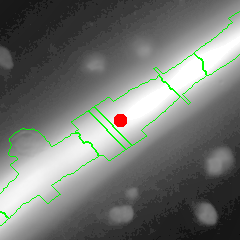
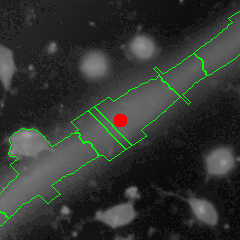
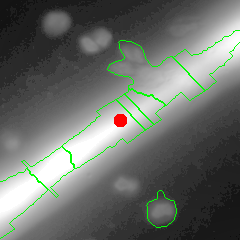
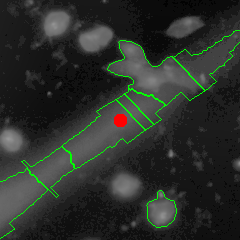
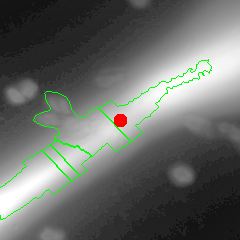
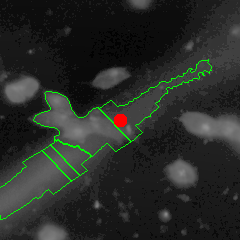
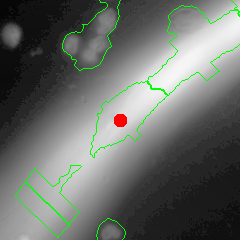
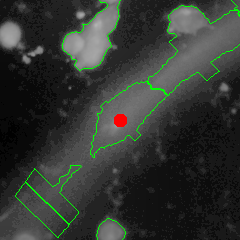

In [13]:
# Find cell outliers for the current plate
cell_outliers_thresholds = {
    # Set low to attempt to detect all instances of abnormally high int in nuclei for whole cells
    "Cells_Intensity_IntegratedIntensity_DNA": 2,
}

cell_outliers = find_outliers(
    df=plate_df,
    metadata_columns=metadata_columns,
    feature_thresholds=cell_outliers_thresholds,
)

if render_diagnostics:
    # MUST SET DATA AS DATAFRAME FOR OUTLINE DIR TO WORK
    cell_outliers_cdf = CytoDataFrame(
        data=pd.DataFrame(cell_outliers),
        data_outline_context_dir=f"/home/jenna/mnt/bandicoot/PCCMA_data/CHP-134_repo1_screen_outputs/SQLite_outputs/{plate_id}",
        segmentation_file_regex=outline_to_orig_mapping_cells,
        display_options={
            "center_dot": True,
            "brightness": 25,
            "offset_bounding_box": {
                "x_min": -120,
                "y_min": -120,
                "x_max": 120,
                "y_max": 120,
            },
        },
    )[
        [
            "Image_FileName_OrigDNA",
            "Image_FileName_OrigAGP",
            "Cells_Intensity_IntegratedIntensity_DNA",
        ]
    ]

    print(cell_outliers_cdf.shape)
    display(
        cell_outliers_cdf.sort_values(
            by="Cells_Intensity_IntegratedIntensity_DNA", ascending=False
        ).head(5)
    )
    # cell_outliers_cdf.sample(n=5, random_state=0)


## Save annotations file for plate with QC flags

In [14]:
# Use label outliers to export qc.parquet file per plate

# Combine every QC condition defined above into one set of named thresholds
qc_feature_thresholds = {
    "nuclei_clustered": nuclei_clustered_thresholds,
    "missegmented_nuclei": missegmented_nuclei_thresholds,
    "background_segmentation": background_segmentation_thresholds,
    "cell_outliers": cell_outliers_thresholds,
}

# export_as_annotations=True keeps only metadata_columns + the generated
# Metadata_cqc_*_is_outlier flags
qc_annotations = label_outliers(
    df=plate_df,
    feature_thresholds=qc_feature_thresholds,
    export_path=str(cleaned_dir / f"{plate_id}_qc_annotations.parquet"),
    export_as_annotations=True,
    annotation_metadata_columns=metadata_columns,
)

# Print the number of outliers and percentage of outliers for each QC condition
qc_annotations.filter(like="Metadata_cqc_").sum().to_frame(name="num_outliers").assign(
    percentage_outliers=lambda x: (x["num_outliers"] / len(qc_annotations)) * 100
)


,num_outliers,percentage_outliers
Metadata_cqc_nuclei_clustered_is_outlier,18041,3.085134
Metadata_cqc_missegmented_nuclei_is_outlier,14455,2.471904
Metadata_cqc_background_segmentation_is_outlier,2411,0.412297
Metadata_cqc_cell_outliers_is_outlier,10961,1.874406
